# Library Type Causal Analysis


In [28]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [29]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_semgrep.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_columns(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
category_order = [
    "<100", "100-500", "500-1k", "1k-5k", "5k-10k", "10k-50k",
    "50k-100k", "100k-500k", "500k-1M", "1M-5M", ">5M",
]
ord_map = {category: index for index, category in enumerate(category_order)}
df["app_popularity_encoded"] = df[popularity_column].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded", "apk_size"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df, rule_id = add_rule_id_columns(df)

print("Popularity column:", popularity_column)
print("Rule ID columns:", len(rule_id))
print(rule_id[:20])


Original rows: 14590
After removing obfuscated: 14590
Popularity column: apk_category
Rule ID columns: 23
['rule_id_gitlab_find_sec_bugs_RSA_NO_PADDING_1', 'rule_id_java_lang_security_audit_cbc_padding_oracle_cbc_padding_oracle', 'rule_id_java_lang_security_audit_crypto_des_is_deprecated_des_is_deprecated', 'rule_id_java_lang_security_audit_crypto_desede_is_deprecated_desede_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ecb_cipher_ecb_cipher', 'rule_id_java_lang_security_audit_crypto_no_null_cipher_no_null_cipher', 'rule_id_java_lang_security_audit_crypto_no_static_initialization_vector_no_static_initialization_vector', 'rule_id_java_lang_security_audit_crypto_rsa_no_padding_rsa_no_padding', 'rule_id_java_lang_security_audit_crypto_ssl_avoid_implementing_custom_digests_avoid_implementing_custom_digests', 'rule_id_java_lang_security_audit_crypto_ssl_defaulthttpclient_is_deprecated_defaulthttpclient_is_deprecated', 'rule_id_java_lang_security_audit_crypto_ssl_insecure_hostname

In [30]:
small_libs = ["SocialMedia", "Analytics", "Cloud", "Advertising"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"
df.loc[df["lib_grouped"] == "others", "lib_grouped"] = "miscellaneous"

print("\nGrouped library counts:")
print(df["lib_grouped"].value_counts())

baseline_name = "App_Source_Code"
libs = [baseline_name] + [lib for lib in df["lib_grouped"].unique() if lib != baseline_name]
print("\nLibrary levels:")
for lib in libs:
    print("-", lib)



Grouped library counts:
lib_grouped
miscellaneous      5787
Android            4769
App_Source_Code    1760
Utilities          1743
Small_Libraries     531
Name: count, dtype: int64

Library levels:
- App_Source_Code
- Android
- miscellaneous
- Utilities
- Small_Libraries


In [31]:
def make_pairwise_balanced(df_in, lib_name, baseline="App_Source_Code", random_state=100):
    df_sub = df_in[df_in["lib_grouped"].isin([baseline, lib_name])].copy()
    baseline_df = df_sub[df_sub["lib_grouped"] == baseline]
    lib_df = df_sub[df_sub["lib_grouped"] == lib_name]
    target_count = len(baseline_df)

    if target_count == 0:
        raise ValueError("No App_Source_Code rows found for the baseline group.")
    if len(lib_df) == 0:
        raise ValueError(f"No rows found for library group: {lib_name}")

    if len(lib_df) >= target_count:
        lib_balanced = lib_df.sample(n=target_count, replace=False, random_state=random_state)
    else:
        lib_balanced = lib_df.sample(n=target_count, replace=True, random_state=random_state)

    df_balanced = pd.concat([baseline_df.copy(), lib_balanced], axis=0)
    return df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200,
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200,
            )
        elif method == "dummy_outcome_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                num_simulations=200,
            )
        else:
            ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

        print_refutation(method, ref)
        ref_rows.append({
            "library": lib_name,
            "setting": label,
            "refuter": method,
            "orig_effect": ate,
            "new_effect": get_refutation_value(ref, "new_effect"),
            "p_value": get_refutation_value(ref, "p_value"),
        })
    return ref_rows


In [32]:
def run_library_contrast(df_sub, lib_name, baseline="App_Source_Code", label="balanced"):
    df_sub = df_sub.copy()
    df_sub["treatment_lib"] = (df_sub["lib_grouped"] == lib_name).astype(int)

    print("\n" + "-" * 14 + f" {lib_name} vs {baseline} " + "-" * 14)

    # Combined approach: treated rows are baseline + selected library; control rows are baseline only.
    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_lib"] == 0].copy()
    df_baseline["combined"] = 0
    df_sub = pd.concat([df_all, df_baseline], ignore_index=True)

    tests.correlation_test_treatment_to_outcome(df_sub)
    print(df_sub["combined"].value_counts())
    n0 = int((df_sub["combined"] == 0).sum())
    n1 = int((df_sub["combined"] == 1).sum())

    common_causes = ["is_3rd_party", "app_popularity_encoded"]

    causal_graph = """
    digraph {
        is_3rd_party -> combined;
        app_popularity_encoded -> combined;
        combined -> verdict;
        app_popularity_encoded -> verdict;
    }
    """

    display(graphviz.Source(causal_graph))

    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=common_causes,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals="bootstrap",
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )

    ate = float(estimate.value)
    try:
        ci_low, ci_high = estimate.get_confidence_intervals()
        ci_low, ci_high = float(ci_low), float(ci_high)
    except Exception:
        ci_low, ci_high = None, None

    print("ATE:", ate)
    if ci_low is not None:
        print("95% CI:", (ci_low, ci_high))

    ref_rows = apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate)

    result_row = {
        "library": lib_name,
        "setting": label,
        "n_baseline": n0,
        "n_treatment": n1,
        "common_causes": ", ".join(common_causes),
        "ATE": ate,
        "CI_low": ci_low,
        "CI_high": ci_high,
    }
    return result_row, ref_rows



-------------- Android vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0619, p = 0.0000

combined
1    3520
0    1760
Name: count, dtype: int64


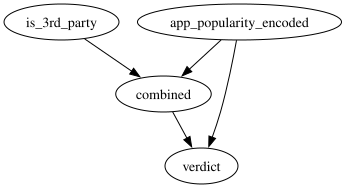

ATE: 0.009469696969696965
95% CI: (-0.2409090909090909, 0.19848484848484846)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.009469696969696965
New effect:0.009469696969696965
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.009469696969696965
New effect:-0.022555871212121215
p value:0.77


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.009469696969696965
New effect:0.027949810606060606
p value:0.9099999999999999


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.0036620993097589184
p value:0.95


-------------- miscellaneous vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0633, p = 0.0000

combined
1    3520
0    1760
Name: count, dtype: int64


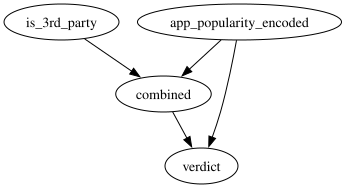

ATE: 0.03238636363636364
95% CI: (-0.22840909090909087, 0.26799242424242425)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.03238636363636364
New effect:0.03238636363636364
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.03238636363636364
New effect:0.005374053030303032
p value:0.96


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.03238636363636364
New effect:0.029372632575757576
p value:0.95


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.025605732747148648
p value:0.9


-------------- Utilities vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0475, p = 0.0006

combined
1    3520
0    1760
Name: count, dtype: int64


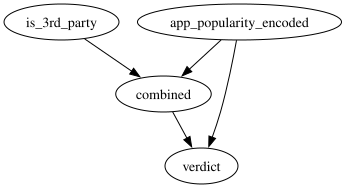

ATE: 0.1625
95% CI: (0.04375000000000001, 0.5132575757575758)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.1625
New effect:0.16250000000000003
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.1625
New effect:-0.006247159090909091
p value:0.91


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.1625
New effect:0.022431344696969693
p value:0.23


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.012265716244927003
p value:0.98


-------------- Small_Libraries vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0752, p = 0.0000

combined
1    3520
0    1760
Name: count, dtype: int64


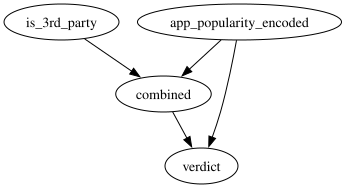

ATE: 0.11041666666666666
95% CI: (-0.08996212121212122, 0.41685606060606056)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:0.11041666666666666
New effect:0.11041666666666666
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:0.11041666666666666
New effect:-0.021107007575757578
p value:0.92


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:0.11041666666666666
New effect:0.05857244318181818
p value:0.74


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.026420042483820783
p value:0.9299999999999999



In [33]:
main_rows = []
ref_rows_all = []

for lib in libs:
    if lib == baseline_name:
        continue

    df_balanced = make_pairwise_balanced(df, lib, baseline=baseline_name, random_state=100)
    main_row, ref_rows = run_library_contrast(df_balanced, lib, baseline=baseline_name, label="balanced")
    main_rows.append(main_row)
    ref_rows_all.extend(ref_rows)


In [34]:
main_df = pd.DataFrame(main_rows).sort_values(["library", "setting"])
ref_df = pd.DataFrame(ref_rows_all)

print("\n\n" + "-" * 25 + " Detailed (ATEs) " + "-" * 25)
print(main_df[["library", "setting", "n_baseline", "n_treatment", "common_causes", "ATE", "CI_low", "CI_high"]])

pivot = main_df.pivot(index="library", columns="setting", values="ATE")
print("\n\n" + "-" * 25 + " Summary ATE " + "-" * 25)
print(pivot)




------------------------- Detailed (ATEs) -------------------------
           library   setting  n_baseline  n_treatment  \
0          Android  balanced        1760         3520   
3  Small_Libraries  balanced        1760         3520   
2        Utilities  balanced        1760         3520   
1    miscellaneous  balanced        1760         3520   

                          common_causes       ATE    CI_low   CI_high  
0  is_3rd_party, app_popularity_encoded  0.009470 -0.240909  0.198485  
3  is_3rd_party, app_popularity_encoded  0.110417 -0.089962  0.416856  
2  is_3rd_party, app_popularity_encoded  0.162500  0.043750  0.513258  
1  is_3rd_party, app_popularity_encoded  0.032386 -0.228409  0.267992  


------------------------- Summary ATE -------------------------
setting          balanced
library                  
Android          0.009470
Small_Libraries  0.110417
Utilities        0.162500
miscellaneous    0.032386
